# HAKS Airbus Corrosion Dataset Analysis

This notebook performs comprehensive analysis of the corrosion prediction dataset:
- Load training and test datasets
- Analyze environmental features
- Train XGBoost classifier
- Analyze and rank feature importance

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, average_precision_score
)
import xgboost as xgb

# Custom dataset loader
from dataset import HAKSDataset, load_haks_data

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Load Datasets

In [2]:
# Initialize dataset loader
dataset = HAKSDataset(data_dir="../haks-airbus-x-ibm-x-aws-2026")

# Load training data
X_train, y_train, train_df = dataset.load_training_data()

# Load test data
X_test, test_df = dataset.load_test_data()

# Get feature names
feature_names = dataset.get_feature_names()

print("Dataset loaded successfully!")
print(f"\nTraining set:")
print(f"  - Features shape: {X_train.shape}")
print(f"  - Labels shape: {y_train.shape}")
print(f"  - Number of features: {len(feature_names)}")
print(f"  - Corrosion cases: {y_train.sum()} / {len(y_train)} ({y_train.mean():.2%})")
print(f"\nTest set:")
print(f"  - Features shape: {X_test.shape}")
print(f"  - Number of aircraft: {test_df['aircraft_id'].nunique()}")

Dataset loaded successfully!

Training set:
  - Features shape: (63524, 33)
  - Labels shape: (63524,)
  - Number of features: 33
  - Corrosion cases: 45110 / 63524 (71.01%)

Test set:
  - Features shape: (14303, 33)
  - Number of aircraft: 142


## 3. Dataset Overview and Statistics

In [3]:
# Get comprehensive dataset info
info = dataset.get_dataset_info()

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
print(f"Training samples: {info['n_train_samples']:,}")
print(f"Test samples: {info['n_test_samples']:,}")
print(f"Number of features: {info['n_features']}")
print(f"Training aircraft: {info['train_aircraft_count']}")
print(f"Test aircraft: {info['test_aircraft_count']}")
print(f"Corrosion cases: {info['n_corrosion_cases']:,}")
print(f"Corrosion rate: {info['corrosion_rate']:.2%}")
print("=" * 60)

DATASET INFORMATION
Training samples: 63,524
Test samples: 14,303
Number of features: 33
Training aircraft: 758
Test aircraft: 142
Corrosion cases: 45,110
Corrosion rate: 71.01%


In [4]:
# Display feature names
print("\nEnvironmental Features:")
print("-" * 60)
for i, feature in enumerate(feature_names, 1):
    print(f"{i:2d}. {feature}")


Environmental Features:
------------------------------------------------------------
 1. total_parking_minutes
 2. metar_temperature_c
 3. metar_relative_humidity
 4. metar_dew_point_c
 5. metar_wind_speed_kn
 6. metar_visibility_mi
 7. metar_hour_precipitation
 8. sea_salt_aerosol_003_05_mixing_ratio
 9. sea_salt_aerosol_05_5_mixing_ratio
10. sea_salt_aerosol_5_20_mixing_ratio
11. dust_aerosol_003_055_mixing_ratio
12. dust_aerosol_055_09_mixing_ratio
13. dust_aerosol_09_20_mixing_ratio
14. hydrophilic_organic_matter_aerosol_mixing_ratio
15. hydrophobic_organic_matter_aerosol_mixing_ratio
16. hydrophilic_black_carbon_aerosol_mixing_ratio
17. hydrophobic_black_carbon_aerosol_mixing_ratio
18. sulphate_aerosol_mixing_ratio
19. ethane
20. c3h8
21. isoprene
22. carbon_monoxide_mass_mixing_ratio
23. ozone_mass_mixing_ratio
24. h2o2
25. formaldehyde
26. hno3
27. nitrogen_monoxide_mass_mixing_ratio
28. nitrogen_dioxide_mass_mixing_ratio
29. oh
30. organic_nitrates
31. specific_humidity
32. su

## 4. Feature Analysis

### 4.1 Basic Statistics

In [5]:
# Create DataFrame for easier analysis
train_features_df = pd.DataFrame(X_train, columns=feature_names)
train_features_df['corrosion'] = y_train

# Display basic statistics
print("Feature Statistics:")
train_features_df[feature_names].describe()

Feature Statistics:


,total_parking_minutes,metar_temperature_c,metar_relative_humidity,metar_dew_point_c,metar_wind_speed_kn,metar_visibility_mi,metar_hour_precipitation,sea_salt_aerosol_003_05_mixing_ratio,sea_salt_aerosol_05_5_mixing_ratio,sea_salt_aerosol_5_20_mixing_ratio,dust_aerosol_003_055_mixing_ratio,dust_aerosol_055_09_mixing_ratio,dust_aerosol_09_20_mixing_ratio,hydrophilic_organic_matter_aerosol_mixing_ratio,hydrophobic_organic_matter_aerosol_mixing_ratio,hydrophilic_black_carbon_aerosol_mixing_ratio,hydrophobic_black_carbon_aerosol_mixing_ratio,sulphate_aerosol_mixing_ratio,ethane,c3h8,isoprene,carbon_monoxide_mass_mixing_ratio,ozone_mass_mixing_ratio,h2o2,formaldehyde,hno3,nitrogen_monoxide_mass_mixing_ratio,nitrogen_dioxide_mass_mixing_ratio,oh,organic_nitrates,specific_humidity,sulphur_dioxide_mass_mixing_ratio,temperature
count,63524.000000,63488.000000,63487.000000,63487.000000,63524.000000,63524.000000,63516.000000,6.352400e+04,6.352400e+04,6.352400e+04,6.352400e+04,6.352400e+04,6.352400e+04,6.352400e+04,6.352400e+04,6.352400e+04,6.352400e+04,6.352400e+04,6.352400e+04,6.352400e+04,6.352400e+04,6.352400e+04,6.352400e+04,6.352400e+04,6.352400e+04,6.352400e+04,6.352400e+04,6.352400e+04,6.352400e+04,6.352400e+04,63524.000000,6.352400e+04,63524.000000
mean,30445.508355,16.513813,67.245746,11.180438,7.139854,6.356767,0.000813,9.206393e-11,7.664622e-09,3.308561e-09,9.236050e-10,1.767347e-09,2.422636e-09,1.307424e-08,8.716168e-09,3.293416e-10,5.035296e-10,4.337488e-09,1.116480e-09,1.139664e-09,5.385720e-09,2.373306e-07,5.261958e-08,6.629142e-10,2.376040e-09,1.626462e-09,3.925087e-09,1.247501e-08,3.724992e-14,1.858148e-09,0.009947,1.330595e-08,290.373316
std,8381.243070,8.272421,18.257788,7.296641,1.786242,1.617738,0.003563,7.181926e-11,6.075969e-09,3.633858e-09,2.075973e-09,4.233108e-09,8.252390e-09,1.817212e-08,1.383237e-08,3.878612e-10,8.350102e-10,8.095804e-09,1.364423e-09,1.966376e-09,7.531755e-09,2.367720e-07,1.513817e-08,5.418851e-10,2.134027e-09,2.298840e-09,9.240778e-09,8.910395e-09,2.274816e-14,1.653642e-09,0.004227,3.646022e-08,7.371558
min,1.050000,-16.453889,1.381661,-20.239208,0.000000,0.190000,0.000000,4.985393e-15,3.769741e-13,2.662750e-13,3.909979e-14,7.060699e-14,4.190920e-14,1.503976e-10,7.141331e-11,3.626260e-12,3.037982e-12,2.466562e-11,1.886788e-10,2.740678e-11,9.999993e-26,4.489305e-08,9.999999e-15,4.270074e-12,5.129457e-11,4.216254e-12,1.529446e-12,8.855178e-11,2.215035e-16,9.587580e-12,0.000784,4.140415e-11,256.088154
25%,25164.791667,9.563114,63.453113,5.305009,5.961638,5.704962,0.000000,4.456727e-11,3.654565e-09,9.779735e-10,9.909771e-11,1.746124e-10,1.036020e-10,4.607017e-09,2.289931e-09,1.225474e-10,1.212142e-10,1.265719e-09,5.286803e-10,3.487971e-10,5.170623e-10,1.397877e-07,4.208780e-08,2.212862e-10,8.996958e-10,6.067321e-10,6.405569e-10,7.377388e-09,2.114360e-14,9.880509e-10,0.006521,1.950105e-09,284.933605
50%,28959.891667,16.858056,72.869789,10.891892,7.009490,5.985442,0.000000,7.450668e-11,6.149368e-09,2.163902e-09,3.036476e-10,5.403883e-10,3.929406e-10,6.930628e-09,3.651760e-09,2.065514e-10,1.856444e-10,2.014187e-09,6.660702e-10,5.688154e-10,2.200810e-09,1.654979e-07,5.188891e-08,5.547921e-10,1.751915e-09,9.937248e-10,1.437501e-09,1.045865e-08,3.549122e-14,1.457708e-09,0.009288,4.157565e-09,290.953202
75%,35905.120833,23.251531,79.206831,16.176368,8.160092,6.157879,0.000000,1.179378e-10,9.823090e-09,4.284726e-09,7.889141e-10,1.430393e-09,1.221830e-09,1.367240e-08,9.308765e-09,3.652932e-10,4.957608e-10,4.563749e-09,1.072918e-09,1.122534e-09,7.349614e-09,2.249574e-07,6.188383e-08,9.950975e-10,3.374727e-09,1.525822e-09,3.175689e-09,1.452690e-08,4.857813e-14,2.214340e-09,0.012817,1.047581e-08,296.443402
max,44640.000000,39.650294,100.000000,27.066209,23.125000,35.187595,0.104874,1.772156e-09,1.512630e-07,1.013043e-07,3.946679e-08,9.110159e-08,1.903317e-07,2.428498e-07,1.792352e-07,6.634335e-09,1.615619e-08,1.641909e-07,1.866632e-08,5.036271e-08,2.217890e-07,3.155315e-06,1.848031e-07,9.425839e-09,5.642228e

### 4.2 Missing Values Analysis

In [6]:
# Check for missing values
missing_train = pd.DataFrame({
    'Feature': feature_names,
    'Missing_Count': [np.isnan(X_train[:, i]).sum() for i in range(len(feature_names))],
    'Missing_Percentage': [np.isnan(X_train[:, i]).mean() * 100 for i in range(len(feature_names))]
})

missing_train = missing_train[missing_train['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

if len(missing_train) > 0:
    print("Features with missing values:")
    print(missing_train)
else:
    print("✓ No missing values found in the dataset")

Features with missing values:
                    Feature  Missing_Count  Missing_Percentage
2   metar_relative_humidity             37            0.058246
3         metar_dew_point_c             37            0.058246
1       metar_temperature_c             36            0.056671
6  metar_hour_precipitation              8            0.012594


### 4.3 Feature Distributions

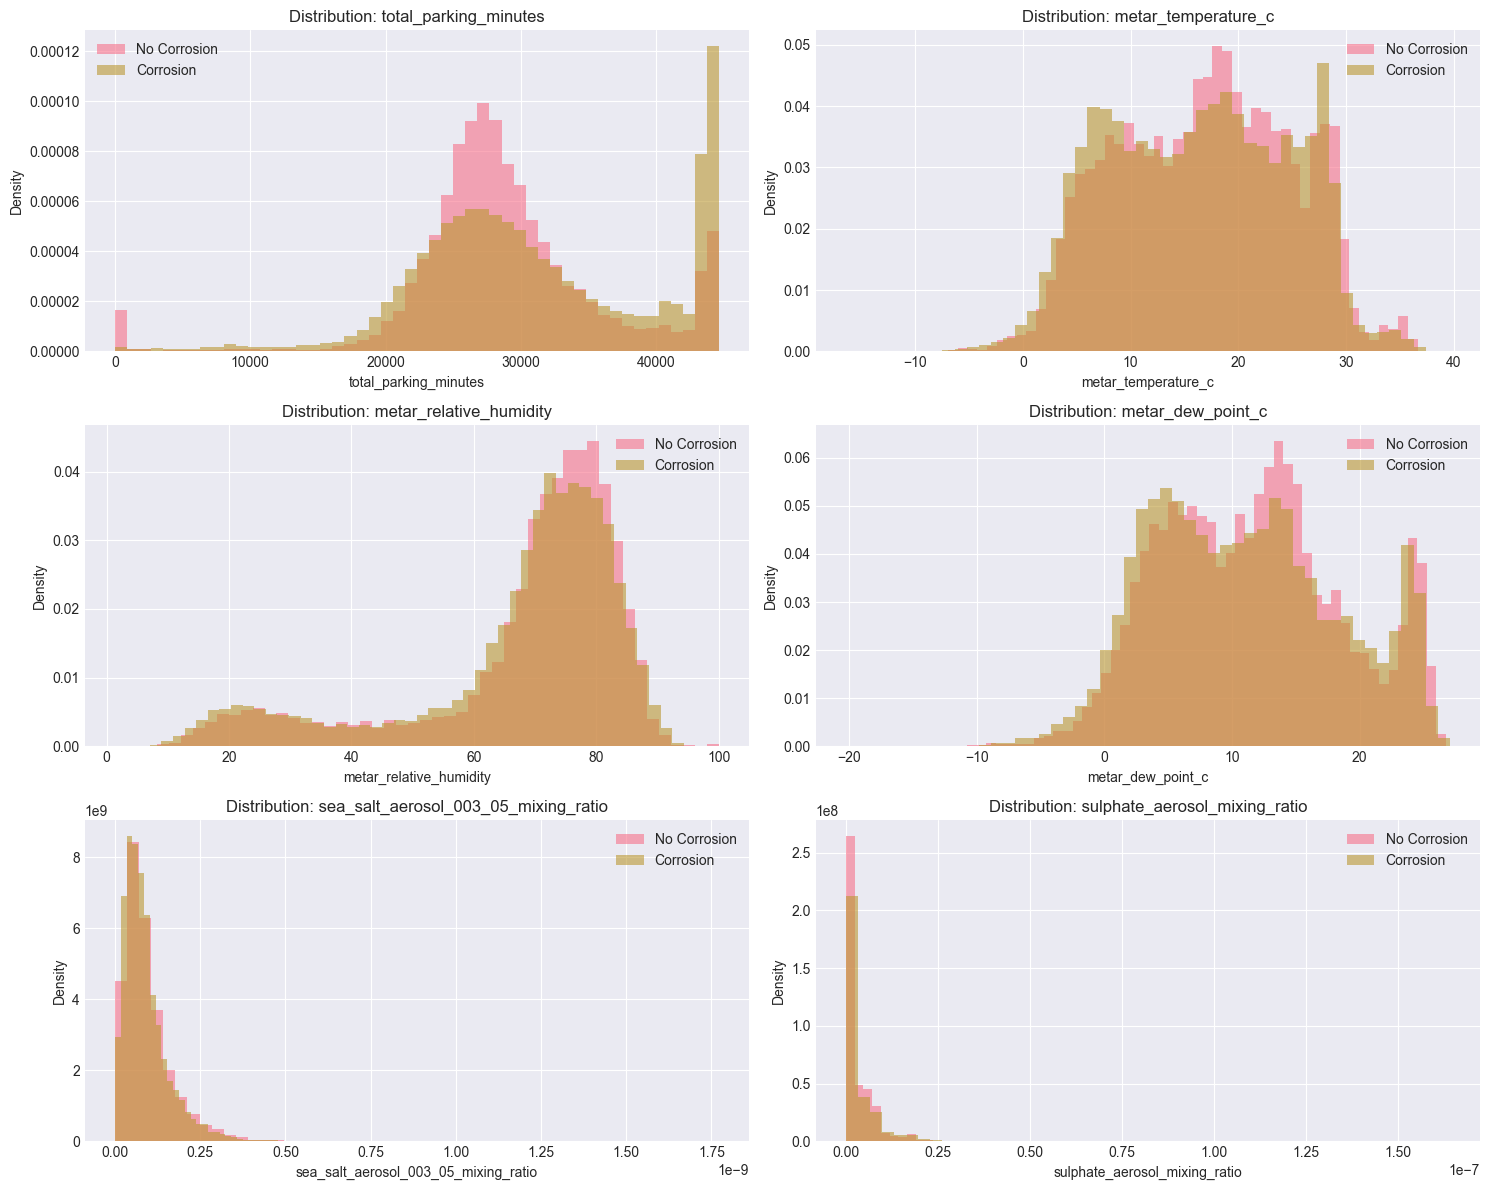

✓ Feature distributions plotted


In [7]:
# Plot distributions of key features
key_features = [
    'total_parking_minutes',
    'metar_temperature_c',
    'metar_relative_humidity',
    'metar_dew_point_c',
    'sea_salt_aerosol_003_05_mixing_ratio',
    'sulphate_aerosol_mixing_ratio'
]

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    feature_idx = feature_names.index(feature)
    
    # Plot for non-corrosion cases
    axes[idx].hist(X_train[y_train == 0, feature_idx], bins=50, alpha=0.6, label='No Corrosion', density=True)
    # Plot for corrosion cases
    axes[idx].hist(X_train[y_train == 1, feature_idx], bins=50, alpha=0.6, label='Corrosion', density=True)
    
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Density')
    axes[idx].legend()
    axes[idx].set_title(f'Distribution: {feature}')

plt.tight_layout()
plt.savefig('../output/feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Feature distributions plotted")

### 4.4 Correlation Analysis

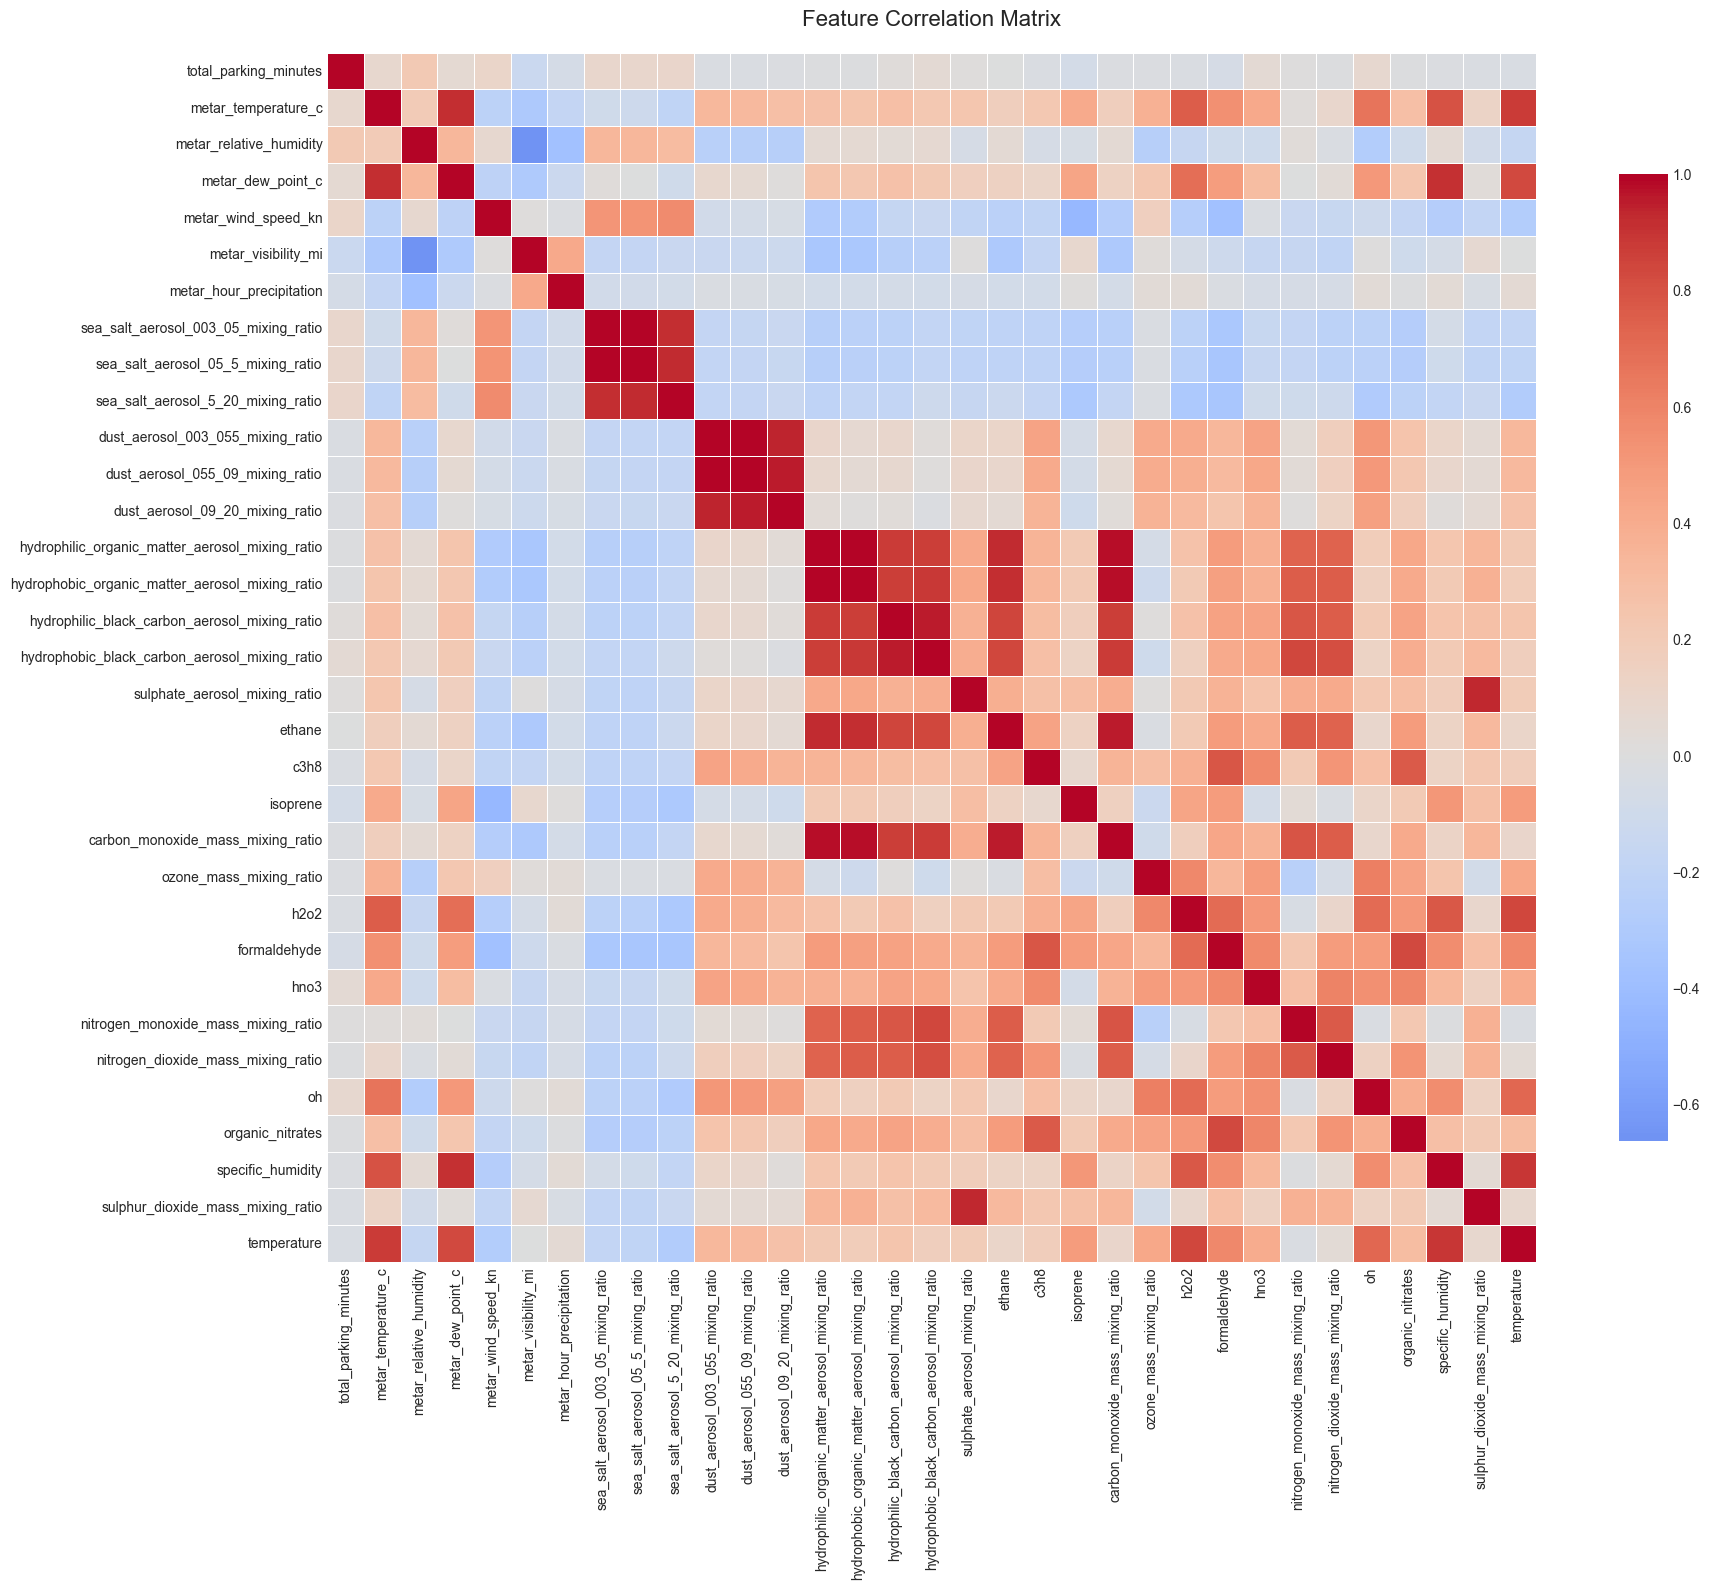

✓ Correlation matrix plotted


In [8]:
# Calculate correlation matrix
correlation_matrix = train_features_df[feature_names].corr()

# Plot correlation heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('../output/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Correlation matrix plotted")

In [9]:
# Find highly correlated features
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    print("\nHighly correlated feature pairs (|r| > 0.8):")
    print("-" * 80)
    for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"{feat1:50s} <-> {feat2:50s}: {corr:6.3f}")
else:
    print("\n✓ No highly correlated feature pairs found (threshold: 0.8)")


Highly correlated feature pairs (|r| > 0.8):
--------------------------------------------------------------------------------
sea_salt_aerosol_003_05_mixing_ratio               <-> sea_salt_aerosol_05_5_mixing_ratio                :  0.999
dust_aerosol_003_055_mixing_ratio                  <-> dust_aerosol_055_09_mixing_ratio                  :  0.996
hydrophilic_organic_matter_aerosol_mixing_ratio    <-> hydrophobic_organic_matter_aerosol_mixing_ratio   :  0.994
hydrophobic_organic_matter_aerosol_mixing_ratio    <-> carbon_monoxide_mass_mixing_ratio                 :  0.980
hydrophilic_organic_matter_aerosol_mixing_ratio    <-> carbon_monoxide_mass_mixing_ratio                 :  0.979
dust_aerosol_055_09_mixing_ratio                   <-> dust_aerosol_09_20_mixing_ratio                   :  0.961
hydrophilic_black_carbon_aerosol_mixing_ratio      <-> hydrophobic_black_carbon_aerosol_mixing_ratio     :  0.955
ethane                                             <-> carbon_monoxide_mass

### 4.5 Feature-Target Correlation


Top 15 Features by Correlation with Corrosion:
 1. total_parking_minutes                             :  0.1150
 2. ozone_mass_mixing_ratio                           : -0.0932
 3. sea_salt_aerosol_5_20_mixing_ratio                : -0.0561
 4. hydrophilic_organic_matter_aerosol_mixing_ratio   :  0.0530
 5. c3h8                                              :  0.0518
 6. carbon_monoxide_mass_mixing_ratio                 :  0.0491
 7. hydrophobic_organic_matter_aerosol_mixing_ratio   :  0.0487
 8. metar_dew_point_c                                 : -0.0394
 9. ethane                                            :  0.0374
10. metar_temperature_c                               : -0.0354
11. sea_salt_aerosol_05_5_mixing_ratio                : -0.0353
12. sea_salt_aerosol_003_05_mixing_ratio              : -0.0351
13. metar_relative_humidity                           : -0.0340
14. nitrogen_monoxide_mass_mixing_ratio               :  0.0326
15. nitrogen_dioxide_mass_mixing_ratio                : 

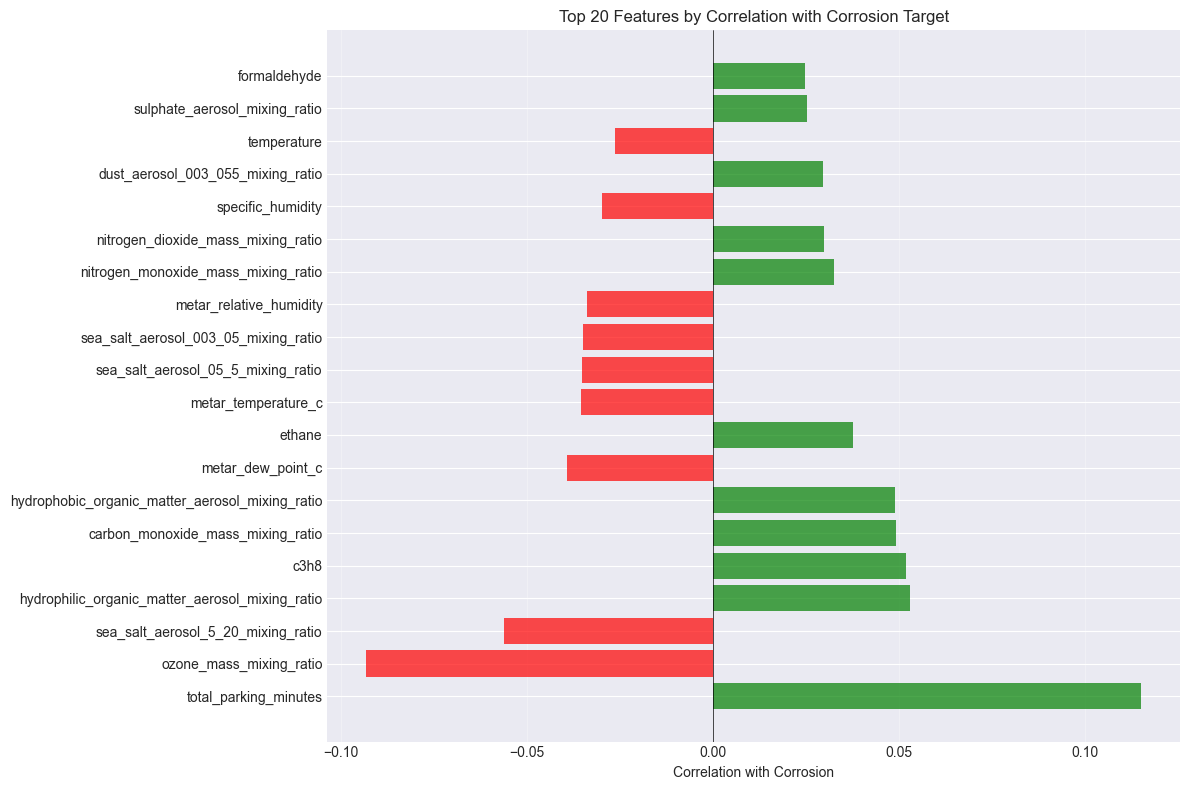


✓ Target correlations analyzed


In [10]:
# Calculate correlation with target
target_correlations = []
for i, feature in enumerate(feature_names):
    # Remove NaN values for correlation calculation
    mask = ~np.isnan(X_train[:, i])
    if mask.sum() > 0:
        corr = np.corrcoef(X_train[mask, i], y_train[mask])[0, 1]
        target_correlations.append((feature, corr))

# Sort by absolute correlation
target_correlations.sort(key=lambda x: abs(x[1]), reverse=True)

# Display top correlations
print("\nTop 15 Features by Correlation with Corrosion:")
print("=" * 70)
for i, (feature, corr) in enumerate(target_correlations[:15], 1):
    print(f"{i:2d}. {feature:50s}: {corr:7.4f}")

# Plot top correlations
top_n = 20
top_features = [x[0] for x in target_correlations[:top_n]]
top_corrs = [x[1] for x in target_correlations[:top_n]]

plt.figure(figsize=(12, 8))
colors = ['red' if x < 0 else 'green' for x in top_corrs]
plt.barh(range(len(top_features)), top_corrs, color=colors, alpha=0.7)
plt.yticks(range(len(top_features)), top_features)
plt.xlabel('Correlation with Corrosion')
plt.title(f'Top {top_n} Features by Correlation with Corrosion Target')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../output/target_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Target correlations analyzed")

## 5. Data Preparation for XGBoost

In [11]:
# Handle any NaN values (replace with median)
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Split training data for validation
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_imputed, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("Data prepared for modeling:")
print(f"  Training set: {X_train_split.shape}")
print(f"  Validation set: {X_val_split.shape}")
print(f"  Test set: {X_test_imputed.shape}")
print(f"\n  Training corrosion rate: {y_train_split.mean():.2%}")
print(f"  Validation corrosion rate: {y_val_split.mean():.2%}")

Data prepared for modeling:
  Training set: (50819, 33)
  Validation set: (12705, 33)
  Test set: (14303, 33)

  Training corrosion rate: 71.01%
  Validation corrosion rate: 71.01%


## 6. XGBoost Model Training

### 6.1 Train Initial Model

In [12]:
# Calculate scale_pos_weight for imbalanced dataset
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Class imbalance ratio: {scale_pos_weight:.2f}")
print(f"Using scale_pos_weight: {scale_pos_weight:.2f}\n")

# Initialize XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=20
)

# Train model with validation set
print("Training XGBoost model...")
xgb_model.fit(
    X_train_split, y_train_split,
    eval_set=[(X_train_split, y_train_split), (X_val_split, y_val_split)],
    verbose=50
)

print("\n✓ Model training completed")

Class imbalance ratio: 0.41
Using scale_pos_weight: 0.41

Training XGBoost model...
[0]	validation_0-logloss:0.67847	validation_1-logloss:0.67923
[50]	validation_0-logloss:0.50437	validation_1-logloss:0.53176
[100]	validation_0-logloss:0.45688	validation_1-logloss:0.50195
[150]	validation_0-logloss:0.42338	validation_1-logloss:0.48496
[199]	validation_0-logloss:0.39749	validation_1-logloss:0.47225

✓ Model training completed


### 6.2 Model Evaluation

In [13]:
# Make predictions
y_train_pred = xgb_model.predict(X_train_split)
y_val_pred = xgb_model.predict(X_val_split)

y_train_pred_proba = xgb_model.predict_proba(X_train_split)[:, 1]
y_val_pred_proba = xgb_model.predict_proba(X_val_split)[:, 1]

# Calculate metrics
train_auc = roc_auc_score(y_train_split, y_train_pred_proba)
val_auc = roc_auc_score(y_val_split, y_val_pred_proba)

print("=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)
print(f"\nTraining AUC-ROC: {train_auc:.4f}")
print(f"Validation AUC-ROC: {val_auc:.4f}")

print("\n" + "=" * 70)
print("VALIDATION SET - Classification Report")
print("=" * 70)
print(classification_report(y_val_split, y_val_pred, target_names=['No Corrosion', 'Corrosion']))

MODEL PERFORMANCE

Training AUC-ROC: 0.9221
Validation AUC-ROC: 0.8504

VALIDATION SET - Classification Report
              precision    recall  f1-score   support

No Corrosion       0.58      0.76      0.66      3683
   Corrosion       0.89      0.78      0.83      9022

    accuracy                           0.77     12705
   macro avg       0.73      0.77      0.74     12705
weighted avg       0.80      0.77      0.78     12705



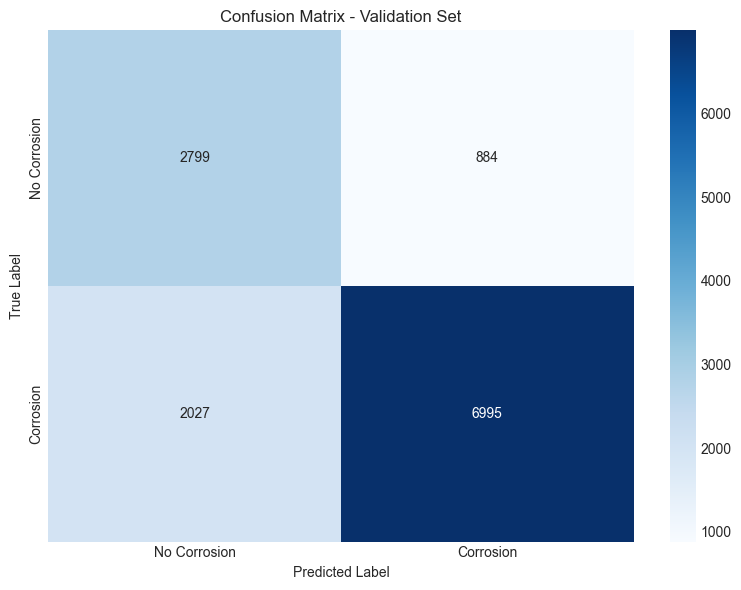

✓ Confusion matrix plotted


In [14]:
# Confusion Matrix
cm = confusion_matrix(y_val_split, y_val_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Corrosion', 'Corrosion'],
            yticklabels=['No Corrosion', 'Corrosion'])
plt.title('Confusion Matrix - Validation Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../output/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrix plotted")

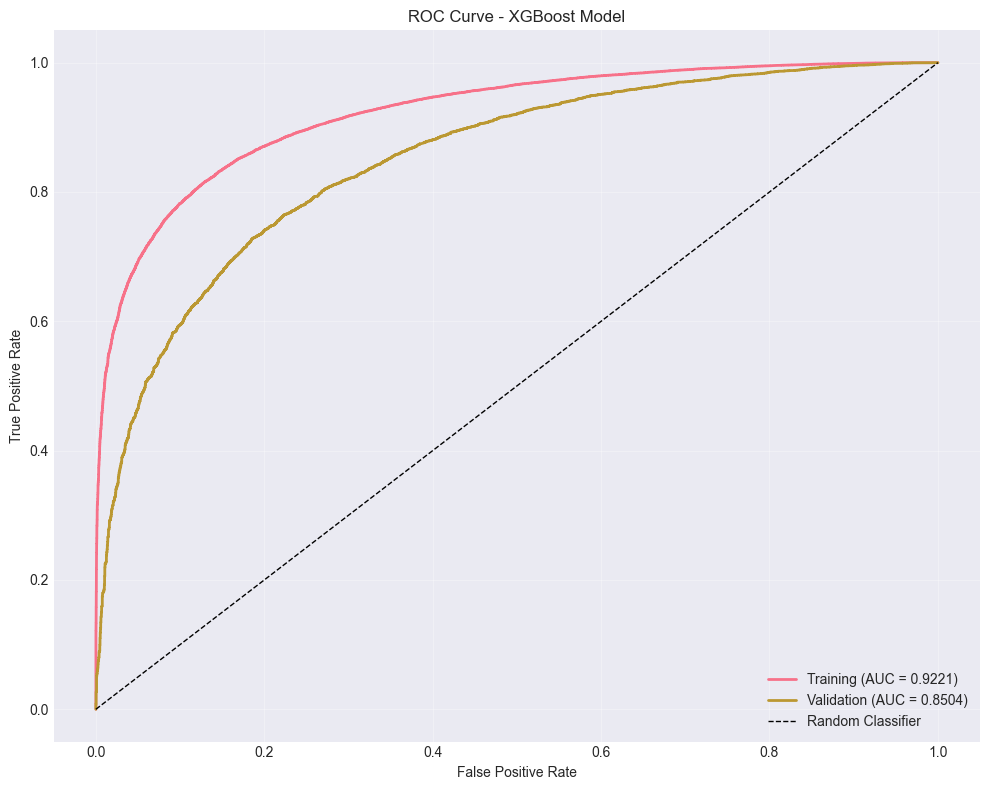

✓ ROC curve plotted


In [15]:
# ROC Curve
fpr_train, tpr_train, _ = roc_curve(y_train_split, y_train_pred_proba)
fpr_val, tpr_val, _ = roc_curve(y_val_split, y_val_pred_proba)

plt.figure(figsize=(10, 8))
plt.plot(fpr_train, tpr_train, label=f'Training (AUC = {train_auc:.4f})', linewidth=2)
plt.plot(fpr_val, tpr_val, label=f'Validation (AUC = {val_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost Model')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../output/roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ ROC curve plotted")

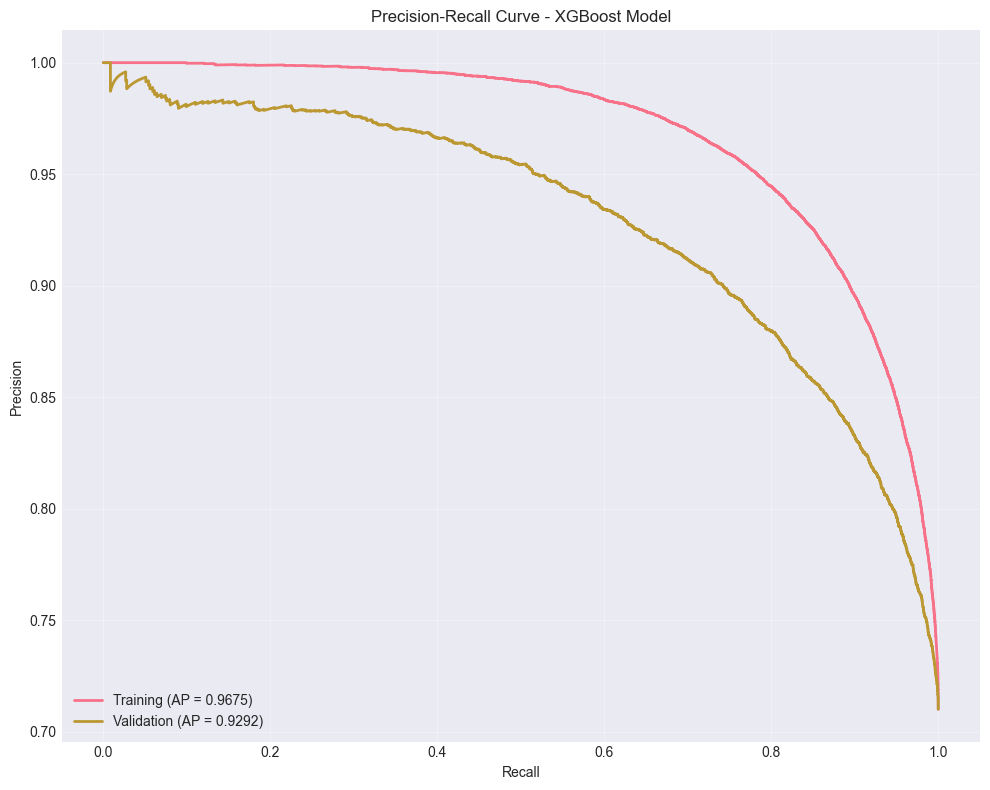

✓ Precision-Recall curve plotted


In [16]:
# Precision-Recall Curve
precision_train, recall_train, _ = precision_recall_curve(y_train_split, y_train_pred_proba)
precision_val, recall_val, _ = precision_recall_curve(y_val_split, y_val_pred_proba)

ap_train = average_precision_score(y_train_split, y_train_pred_proba)
ap_val = average_precision_score(y_val_split, y_val_pred_proba)

plt.figure(figsize=(10, 8))
plt.plot(recall_train, precision_train, label=f'Training (AP = {ap_train:.4f})', linewidth=2)
plt.plot(recall_val, precision_val, label=f'Validation (AP = {ap_val:.4f})', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - XGBoost Model')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../output/precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Precision-Recall curve plotted")

## 7. Feature Importance Analysis

### 7.1 XGBoost Built-in Feature Importance

TOP 20 MOST IMPORTANT FEATURES (XGBoost)
                                        Feature  Importance
                          total_parking_minutes    0.066904
              carbon_monoxide_mass_mixing_ratio    0.044744
                        ozone_mass_mixing_ratio    0.042207
                                         ethane    0.040171
              sulphur_dioxide_mass_mixing_ratio    0.037833
  hydrophilic_black_carbon_aerosol_mixing_ratio    0.036669
                                           hno3    0.036364
                  sulphate_aerosol_mixing_ratio    0.034353
                                           c3h8    0.033937
hydrophilic_organic_matter_aerosol_mixing_ratio    0.032607
             nitrogen_dioxide_mass_mixing_ratio    0.031395
           sea_salt_aerosol_003_05_mixing_ratio    0.030065
hydrophobic_organic_matter_aerosol_mixing_ratio    0.029636
                            metar_visibility_mi    0.029105
                            metar_temperature_c    0.028449

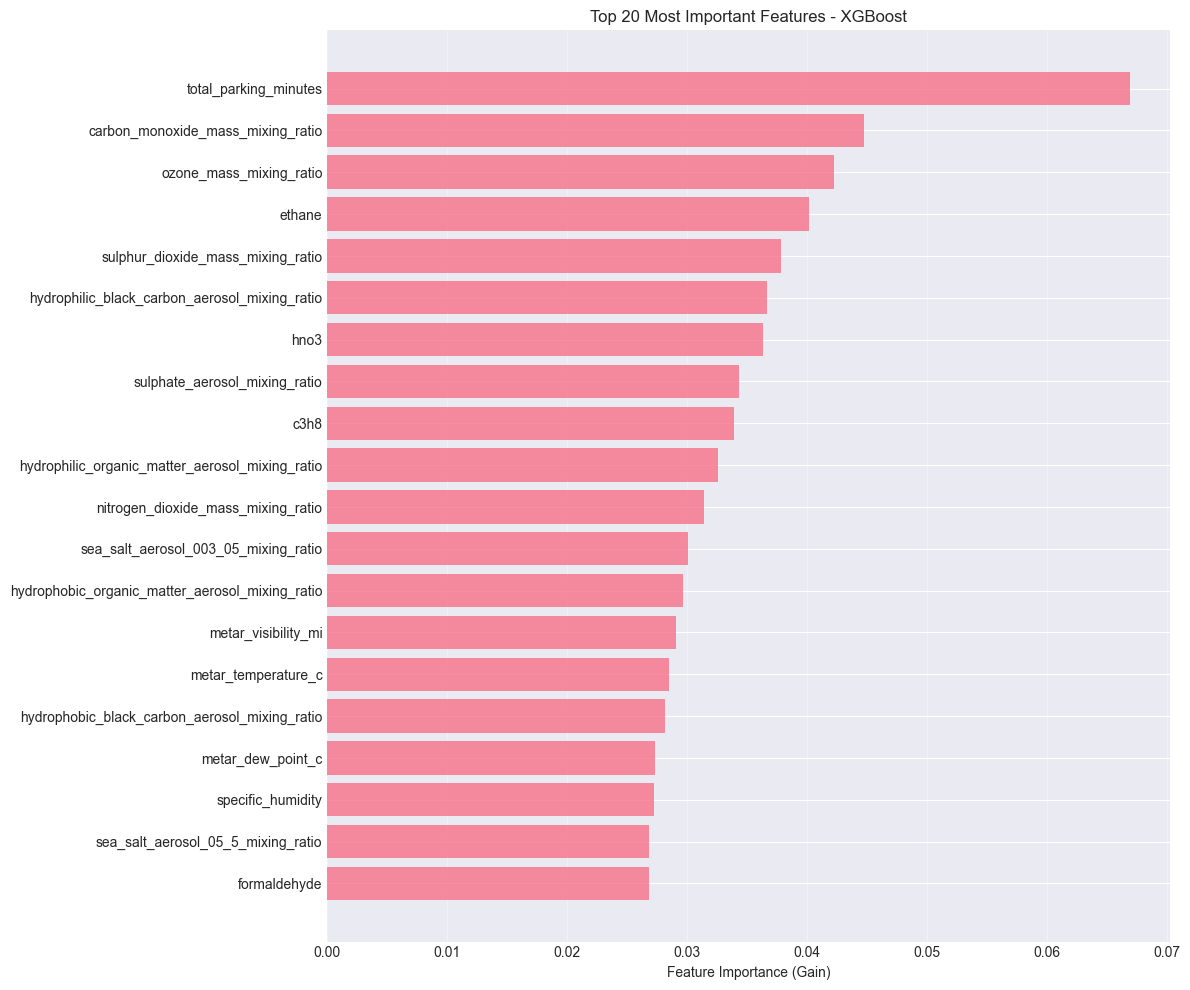


✓ Feature importance plotted


In [17]:
# Get feature importance
feature_importance = xgb_model.feature_importances_

# Create DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

# Display top features
print("=" * 70)
print("TOP 20 MOST IMPORTANT FEATURES (XGBoost)")
print("=" * 70)
print(importance_df.head(20).to_string(index=False))

# Plot feature importance
top_n = 20
top_importance = importance_df.head(top_n)

plt.figure(figsize=(12, 10))
plt.barh(range(len(top_importance)), top_importance['Importance'], alpha=0.8)
plt.yticks(range(len(top_importance)), top_importance['Feature'])
plt.xlabel('Feature Importance (Gain)')
plt.title(f'Top {top_n} Most Important Features - XGBoost')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../output/feature_importance_xgboost.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Feature importance plotted")

### 7.2 Feature Importance by Type


FEATURE IMPORTANCE BY CATEGORY
Aerosols                      : 0.3101
Other                         : 0.2368
Chemical Compounds            : 0.1777
METAR (Weather)               : 0.1596
Parking Time                  : 0.0669
Atmospheric Conditions        : 0.0489


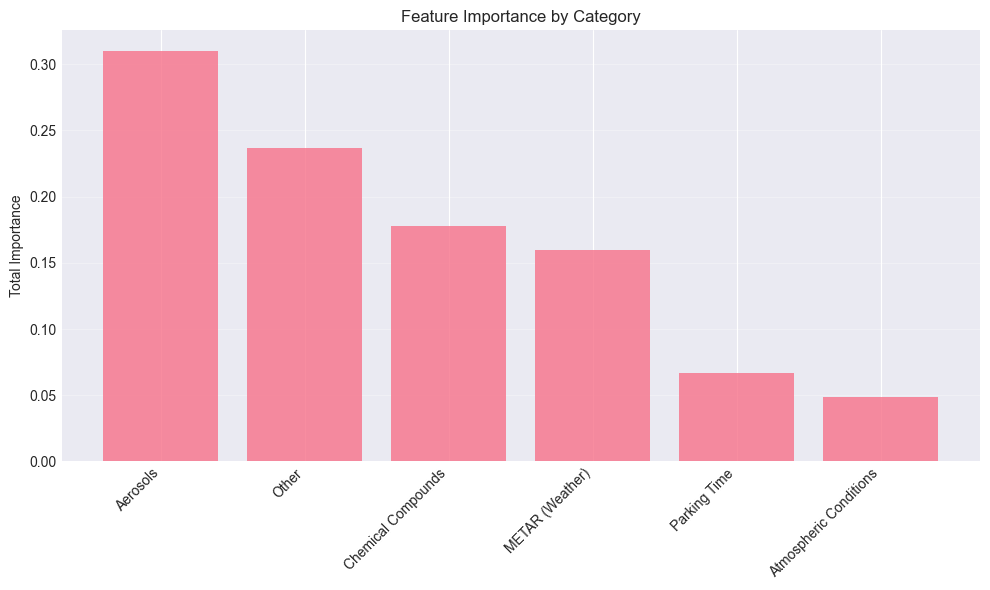


✓ Category importance plotted


In [18]:
# Categorize features
def categorize_feature(feature_name):
    if 'metar' in feature_name:
        return 'METAR (Weather)'
    elif 'aerosol' in feature_name:
        return 'Aerosols'
    elif any(x in feature_name for x in ['carbon', 'nitrogen', 'sulphur', 'ozone']):
        return 'Chemical Compounds'
    elif 'parking' in feature_name:
        return 'Parking Time'
    elif feature_name in ['temperature', 'specific_humidity']:
        return 'Atmospheric Conditions'
    else:
        return 'Other'

importance_df['Category'] = importance_df['Feature'].apply(categorize_feature)

# Aggregate importance by category
category_importance = importance_df.groupby('Category')['Importance'].sum().sort_values(ascending=False)

print("\n" + "=" * 70)
print("FEATURE IMPORTANCE BY CATEGORY")
print("=" * 70)
for category, importance in category_importance.items():
    print(f"{category:30s}: {importance:.4f}")

# Plot category importance
plt.figure(figsize=(10, 6))
plt.bar(range(len(category_importance)), category_importance.values, alpha=0.8)
plt.xticks(range(len(category_importance)), category_importance.index, rotation=45, ha='right')
plt.ylabel('Total Importance')
plt.title('Feature Importance by Category')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../output/feature_importance_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Category importance plotted")

### 7.3 Complete Feature Ranking

In [19]:
# Complete ranking with additional metrics
complete_ranking = importance_df.copy()
complete_ranking['Rank'] = range(1, len(complete_ranking) + 1)
complete_ranking['Cumulative_Importance'] = complete_ranking['Importance'].cumsum()
complete_ranking['Importance_Percentage'] = (complete_ranking['Importance'] / complete_ranking['Importance'].sum()) * 100
complete_ranking['Cumulative_Percentage'] = complete_ranking['Importance_Percentage'].cumsum()

print("\n" + "=" * 100)
print("COMPLETE FEATURE RANKING")
print("=" * 100)
print(complete_ranking[['Rank', 'Feature', 'Category', 'Importance', 'Importance_Percentage', 'Cumulative_Percentage']].to_string(index=False))

# Save to CSV
complete_ranking.to_csv('../output/feature_ranking.csv', index=False)
print("\n✓ Complete feature ranking saved to '../output/feature_ranking.csv'")


COMPLETE FEATURE RANKING
 Rank                                         Feature               Category  Importance  Importance_Percentage  Cumulative_Percentage
    1                           total_parking_minutes           Parking Time    0.066904               6.690402               6.690402
    2               carbon_monoxide_mass_mixing_ratio     Chemical Compounds    0.044744               4.474386              11.164787
    3                         ozone_mass_mixing_ratio     Chemical Compounds    0.042207               4.220711              15.385498
    4                                          ethane                  Other    0.040171               4.017076              19.402575
    5               sulphur_dioxide_mass_mixing_ratio     Chemical Compounds    0.037833               3.783339              23.185913
    6   hydrophilic_black_carbon_aerosol_mixing_ratio               Aerosols    0.036669               3.666920              26.852833
    7                        

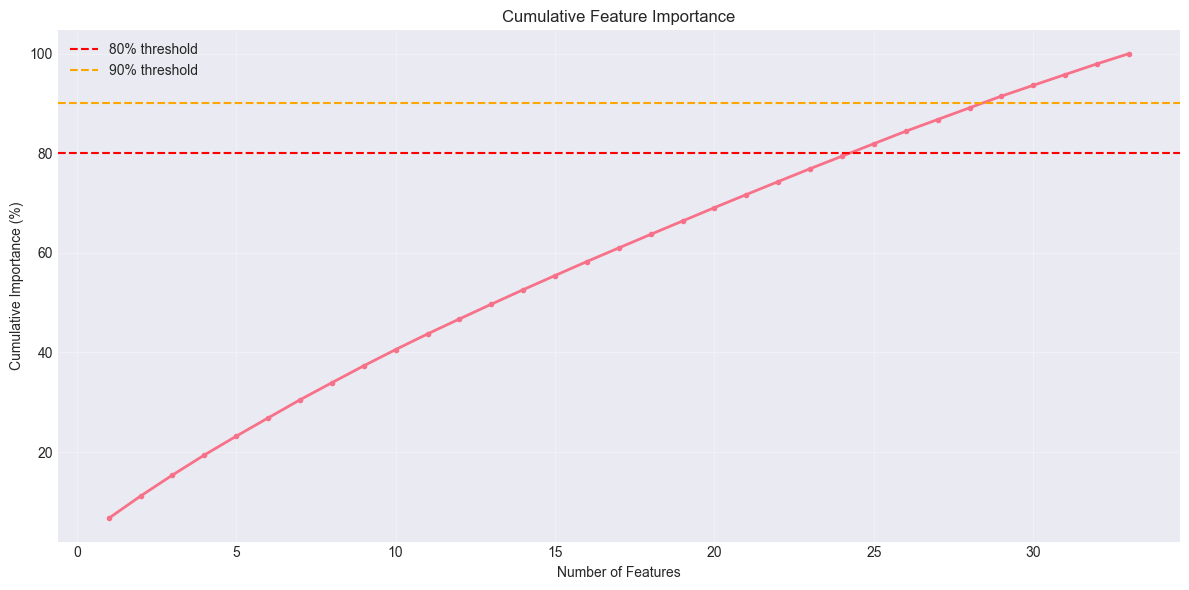


Number of features for 80% cumulative importance: 25
Number of features for 90% cumulative importance: 29

✓ Cumulative importance analysis completed


In [20]:
# Plot cumulative importance
plt.figure(figsize=(12, 6))
plt.plot(complete_ranking['Rank'], complete_ranking['Cumulative_Percentage'], linewidth=2, marker='o', markersize=3)
plt.axhline(y=80, color='r', linestyle='--', label='80% threshold')
plt.axhline(y=90, color='orange', linestyle='--', label='90% threshold')
plt.xlabel('Number of Features')
plt.ylabel('Cumulative Importance (%)')
plt.title('Cumulative Feature Importance')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('../output/cumulative_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Find number of features for 80% and 90% importance
n_features_80 = (complete_ranking['Cumulative_Percentage'] <= 80).sum() + 1
n_features_90 = (complete_ranking['Cumulative_Percentage'] <= 90).sum() + 1

print(f"\nNumber of features for 80% cumulative importance: {n_features_80}")
print(f"Number of features for 90% cumulative importance: {n_features_90}")
print("\n✓ Cumulative importance analysis completed")

## 8. Cross-Validation

In [21]:
# Perform stratified k-fold cross-validation
print("Performing 5-fold cross-validation...\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_model, X_train_imputed, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print("=" * 70)
print("CROSS-VALIDATION RESULTS (AUC-ROC)")
print("=" * 70)
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: {score:.4f}")
print("-" * 70)
print(f"Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print("=" * 70)

# Plot CV scores
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(cv_scores) + 1), cv_scores, alpha=0.8)
plt.axhline(y=cv_scores.mean(), color='r', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('AUC-ROC Score')
plt.title('Cross-Validation Scores')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../output/cv_scores.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Cross-validation completed")

Performing 5-fold cross-validation...



ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/miniconda3/lib/python3.13/site-packages/xgboost/core.py", line 774, in inner_f
    return func(**kwargs)
  File "/opt/miniconda3/lib/python3.13/site-packages/xgboost/sklearn.py", line 1808, in fit
    self._Booster = train(
                    ~~~~~^
        params,
        ^^^^^^^
    ...<9 lines>...
        callbacks=self.callbacks,
        ^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/opt/miniconda3/lib/pyt

## 9. Summary and Conclusions

In [ ]:
print("\n" + "=" * 80)
print("ANALYSIS SUMMARY")
print("=" * 80)

print("\n1. DATASET OVERVIEW:")
print(f"   - Training samples: {info['n_train_samples']:,}")
print(f"   - Test samples: {info['n_test_samples']:,}")
print(f"   - Number of features: {info['n_features']}")
print(f"   - Corrosion rate: {info['corrosion_rate']:.2%}")

print("\n2. MODEL PERFORMANCE:")
print(f"   - Validation AUC-ROC: {val_auc:.4f}")
print(f"   - Cross-validation AUC-ROC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"   - Average Precision: {ap_val:.4f}")

print("\n3. TOP 5 MOST IMPORTANT FEATURES:")
for i, row in complete_ranking.head(5).iterrows():
    print(f"   {row['Rank']}. {row['Feature']:50s} ({row['Importance_Percentage']:.2f}%)")

print("\n4. FEATURE CATEGORIES BY IMPORTANCE:")
for category, importance in category_importance.head(3).items():
    pct = (importance / category_importance.sum()) * 100
    print(f"   - {category:30s}: {pct:.2f}%")

print("\n5. KEY INSIGHTS:")
print(f"   - {n_features_80} features account for 80% of model importance")
print(f"   - {n_features_90} features account for 90% of model importance")
print(f"   - Class imbalance ratio: {scale_pos_weight:.2f}:1")

print("\n" + "=" * 80)
print("All visualizations saved to '../output/' directory")
print("Feature ranking saved to '../output/feature_ranking.csv'")
print("=" * 80)

## 10. Generate Predictions for Test Set

In [ ]:
# Train final model on full training data
print("Training final model on full training data...")
final_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

final_model.fit(X_train_imputed, y_train)

# Generate predictions
test_predictions = final_model.predict_proba(X_test_imputed)[:, 1]

# Create submission file
submission = test_df[['aircraft_id', 'year_month']].copy()
submission['id'] = submission['aircraft_id'] + '_' + submission['year_month']
submission['corrosion_risk'] = test_predictions
submission = submission[['id', 'corrosion_risk']]

# Save submission
submission.to_csv('../output/submission.csv', index=False)

print("\n✓ Test predictions generated")
print(f"✓ Submission file saved to '../output/submission.csv'")
print(f"\nPrediction statistics:")
print(f"  Mean corrosion risk: {test_predictions.mean():.4f}")
print(f"  Std corrosion risk: {test_predictions.std():.4f}")
print(f"  Min corrosion risk: {test_predictions.min():.4f}")
print(f"  Max corrosion risk: {test_predictions.max():.4f}")

# Display sample predictions
print("\nSample predictions:")
print(submission.head(10))

## Analysis Complete! 🎉

This notebook has:
1. ✅ Loaded and analyzed the corrosion prediction dataset
2. ✅ Performed comprehensive feature analysis
3. ✅ Trained an XGBoost classifier
4. ✅ Evaluated model performance with multiple metrics
5. ✅ Analyzed and ranked feature importance
6. ✅ Generated predictions for the test set

All results and visualizations have been saved to the `output/` directory.